# Factor Experiment Analysis
RMSE summary tables and Diebold-Mariano tests across all AE architectures and time series models.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats

RESULTS = Path('factor_experiment')
ERRORS  = Path('errors')

AE_ORDER = ['VanillaAE', 'DenoisingAE', 'SparseAE', 'ContractiveAE',
            'VAE', 'BetaVAE', 'RecurrentAE', 'MaskedAE']
TS_ORDER = ['FA_AR_AIC', 'FA_AR_BIC', 'FA_MA_AIC', 'FA_MA_BIC',
            'FA_ARIMA_AIC', 'FA_ARIMA_BIC', 'FA_GARCH']
TS_LABELS = {
    'FA_AR_AIC':    'AR (AIC)',
    'FA_AR_BIC':    'AR (BIC)',
    'FA_MA_AIC':    'MA (AIC)',
    'FA_MA_BIC':    'MA (BIC)',
    'FA_ARIMA_AIC': 'ARIMA (AIC)',
    'FA_ARIMA_BIC': 'ARIMA (BIC)',
    'FA_GARCH':     'GARCH',
}
# Classical TS key -> (display label, matching AE+TS column)
CLASSICAL_MAP = {
    'AR_AIC':          ('AR (AIC)',    'FA_AR_AIC'),
    'AR_BIC':          ('AR (BIC)',    'FA_AR_BIC'),
    'MA_AIC':          ('MA (AIC)',    'FA_MA_AIC'),
    'MA_BIC':          ('MA (BIC)',    'FA_MA_BIC'),
    'ARIMA_AIC_fixed': ('ARIMA (AIC)', 'FA_ARIMA_AIC'),
    'ARIMA_BIC_fixed': ('ARIMA (BIC)', 'FA_ARIMA_BIC'),
    'GARCH11':         ('GARCH(1,1)', 'FA_GARCH'),
}


def dm_test(err_a, err_b, max_lag=10):
    # Pooled DM test with Newey-West HAC variance.
    # Negative stat => err_a has lower MSE than err_b (err_a is better).
    idx  = err_a.index.intersection(err_b.index)
    cols = err_a.columns.intersection(err_b.columns)
    d = ((err_a.loc[idx, cols] ** 2) - (err_b.loc[idx, cols] ** 2)).values.flatten()
    d = d[np.isfinite(d)]
    n = len(d)
    d_mean = d.mean()
    gamma0  = np.mean((d - d_mean) ** 2)
    hac_var = gamma0
    for lag in range(1, max_lag + 1):
        gamma_l  = np.mean((d[lag:] - d_mean) * (d[:-lag] - d_mean))
        hac_var += 2 * (1 - lag / (max_lag + 1)) * gamma_l
    hac_var  = max(hac_var, 1e-12)
    dm_stat  = d_mean / np.sqrt(hac_var / n)
    p_value  = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return float(dm_stat), float(p_value)

In [2]:
import re

# Load reconstruction summary
recon = pd.read_csv(RESULTS / 'summary_reconstruction.csv', index_col=0)
recon.index.name = 'AE'
recon = recon.reindex([a for a in AE_ORDER if a in recon.index])
comm_cols = [c for c in recon.columns if c != 'ALL']

# Load forecast summary and pivot to AE x TS
fc_raw = pd.read_csv(RESULTS / 'summary_forecast.csv', index_col=0)
fc_raw['AE']       = fc_raw.index.map(lambda x: x.split(' / ')[0])
fc_raw['TS_model'] = fc_raw.index.map(lambda x: x.split(' / ')[1])
fc_raw['pooled_mse'] = fc_raw['pooled_mse'].astype(float)
fc_pivot = fc_raw.pivot(index='AE', columns='TS_model', values='pooled_mse')
fc_pivot = fc_pivot.reindex(
    index=[a for a in AE_ORDER if a in fc_pivot.index],
    columns=[t for t in TS_ORDER if t in fc_pivot.columns])

# Parse dominant (most-selected) lag from lag_selection string
def _dominant_lag(s):
    if not s or pd.isna(s):
        return ''
    first = str(s).split('×')[0].strip()   # split on ×
    ma = re.match(r'^MA\((\d+)\)$', first)
    if ma:
        return f'MA(0,{ma.group(1)})'
    arima = re.match(r'^ARIMA\((\d+),\s*(\d+),\s*(\d+)\)$', first)
    if arima:
        p, d, q = arima.groups()
        return f'ARIMA({p},{d},{q})'
    return first

fc_raw['dominant_lag'] = fc_raw['lag_selection'].apply(_dominant_lag)
lag_pivot = fc_raw.pivot(index='AE', columns='TS_model', values='dominant_lag')
lag_pivot = lag_pivot.reindex(
    index=[a for a in AE_ORDER if a in lag_pivot.index],
    columns=[t for t in TS_ORDER if t in lag_pivot.columns])

# Load per-date error series
recon_errors, fc_errors = {}, {}
for ae in AE_ORDER:
    arch_dir = RESULTS / ae
    if not arch_dir.exists():
        continue
    rp = arch_dir / 'recon_errors.csv'
    if rp.exists():
        recon_errors[ae] = pd.read_csv(rp, index_col=0, parse_dates=True)
    for ts in TS_ORDER:
        p = arch_dir / f'{ts}_errors.csv'
        if p.exists():
            fc_errors[f'{ae}/{ts}'] = pd.read_csv(p, index_col=0, parse_dates=True)

classical_errors = {}
for key in CLASSICAL_MAP:
    p = ERRORS / f'{key}_errors.csv'
    if p.exists():
        classical_errors[key] = pd.read_csv(p, index_col=0, parse_dates=True)

print(f'Loaded: {len(recon_errors)} AE recon | {len(fc_errors)} AE+TS | {len(classical_errors)} classical')

Loaded: 8 AE recon | 56 AE+TS | 7 classical


## 1. Autoencoders Only

In [3]:
print('1a. RMSE per Commodity')
display(np.sqrt(recon[comm_cols]).round(4))

1a. RMSE per Commodity


,Brent,WTI,NaturalGas,Gasoline,Diesel,Gold,Silver,Copper,Aluminium,Nickel,...,Corn,Cotton,LeanHogs,LiveCattle,Sugar,Soybeans,SoybeanMeal,SoybeanOil,HRWWheat,Wheat
AE,,,,,,,,,,,,,,,,,,,,,
VanillaAE,0.5214,0.5878,0.8388,0.6458,0.5734,0.7130,0.6820,0.6200,0.6825,0.7102,...,0.6663,0.8643,0.9287,0.9081,0.8287,0.6109,0.7198,0.7432,0.5833,0.5965
DenoisingAE,0.5195,0.5907,0.8417,0.6450,0.5729,0.7153,0.6836,0.6178,0.6815,0.7102,...,0.6661,0.8649,0.9322,0.9099,0.8295,0.6091,0.7218,0.7411,0.5812,0.5954
SparseAE,0.5188,0.5857,0.8385,0.6434,0.5712,0.7115,0.6803,0.6189,0.6807,0.7099,...,0.6649,0.8637,0.9264,0.9076,0.8273,0.6092,0.7183,0.7420,0.5829,0.5962
ContractiveAE,0.5108,0.5821,0.8360,0.6384,0.5655,0.7113,0.6773,0.6149,0.6793,0.7078,...,0.6602,0.8649,0.9248,0.9075,0.8251,0.6012,0.7131,0.7395,0.5813,0.5951
VAE,0.6004,0.6639,0.9481,0.6992,0.6366,0.8112,0.7699,0.6616,0.7306,0.7368,...,0.6957,0.9141,0.9877,0.9729,0.9042,0.6701,0.7967,0.7607,0.6626,0.6699
BetaVAE,0.7744,0.8057,0.9802,0.8331,0.7998,0.9050,0.8809,0.7952,0.8368,0.8258,...,0.8599,0.9416,1.0059,0.9883,0.9353,0.8215,0.9216,0.8214,0.8745,0.8768
RecurrentAE,0.6268,0.7231,1.0921,0.7818,0.6919,0.8387,0.8114,0.7318,0.8256,0.8791,...,0.8047,1.0811,1.1480,1.1180,1.0512,0.7495,0.8995,0.9174,0.7178,0.7345
MaskedAE,0.5590,0.6335,0.9856,0.6813,0.6145,0.8613,0.8258,0.6847,0.7579,0.7644,...,0.7132,0.9459,1.0132,1.0037,0.9467,0.6940,0.8200,0.7986,0.6844,0.7002


In [4]:
print('1b. Pooled MSE, RMSE, and R-squared across all 22 commodities')
mse = recon['ALL'].rename('MSE')
pooled = pd.DataFrame({
    'MSE':  mse.round(5),
    'RMSE': np.sqrt(mse).round(5),
    'R2 (Variance Explained)': (1 - mse).round(5),
})
pooled.index.name = 'AE'
display(pooled.sort_values('RMSE'))

1b. Pooled MSE, RMSE, and R-squared across all 22 commodities


,MSE,RMSE,R2 (Variance Explained)
AE,,,
ContractiveAE,0.50216,0.70863,0.49784
SparseAE,0.50596,0.71131,0.49404
VanillaAE,0.50775,0.71257,0.49225
DenoisingAE,0.50820,0.71288,0.49180
VAE,0.60106,0.77528,0.39894
MaskedAE,0.63792,0.79870,0.36208
BetaVAE,0.76775,0.87621,0.23225
RecurrentAE,0.77052,0.87780,0.22948


## 2. Autoencoders + Time Series

In [5]:
fc_rmse = np.sqrt(fc_pivot)

# Build flat tables for RMSE and dominant lag, then merge
rmse_long = fc_rmse.rename(columns=TS_LABELS).stack().reset_index()
rmse_long.columns = ['AE', 'TS Model', 'RMSE']

lag_long = lag_pivot.rename(columns=TS_LABELS).stack().reset_index()
lag_long.columns = ['AE', 'TS Model', 'Dominant Lag']

fc_long = (rmse_long
           .merge(lag_long, on=['AE', 'TS Model'])
           .assign(RMSE=lambda d: d['RMSE'].round(5))
           .sort_values(['AE', 'RMSE'])
           .reset_index(drop=True))

print('2a. AE + Time Series: AE | TS Model | Dominant Lag | RMSE')
display(fc_long[['AE', 'TS Model', 'Dominant Lag', 'RMSE']])

2a. AE + Time Series: AE | TS Model | Dominant Lag | RMSE


,AE,TS Model,Dominant Lag,RMSE
0,BetaVAE,MA (BIC),"MA(0,1)",0.99363
1,BetaVAE,GARCH,"GARCH(1,1)",0.99366
2,BetaVAE,AR (BIC),AR(1),0.99410
3,BetaVAE,MA (AIC),"MA(0,1)",0.99428
4,BetaVAE,ARIMA (BIC),"ARIMA(1,0,0)",0.99430
5,BetaVAE,AR (AIC),AR(1),0.99457
6,BetaVAE,ARIMA (AIC),"ARIMA(1,0,0)",0.99549
7,ContractiveAE,GARCH,"GARCH(1,1)",0.99454
8,ContractiveAE,MA (BIC),"MA(0,1)",0.99465
9,ContractiveAE,AR (BIC),AR(1),0.99573


In [6]:
best_ts   = fc_rmse.idxmin(axis=1).map(TS_LABELS).rename('Best TS Model')
best_rmse = fc_rmse.min(axis=1).rename('Best RMSE').round(5)
print('2b. Best TS Model per AE')
display(pd.concat([best_ts, best_rmse], axis=1))

2b. Best TS Model per AE


,Best TS Model,Best RMSE
AE,,
VanillaAE,GARCH,0.99482
DenoisingAE,GARCH,0.99476
SparseAE,GARCH,0.99477
ContractiveAE,GARCH,0.99454
VAE,GARCH,0.99433
BetaVAE,MA (BIC),0.99363
RecurrentAE,GARCH,1.08430
MaskedAE,GARCH,0.99460


## 3. Time Series Only

In [7]:
cl_rows = {}
for key, (label, _) in CLASSICAL_MAP.items():
    if key not in classical_errors:
        continue
    err = classical_errors[key]
    row = (err ** 2).mean(axis=0).to_dict()
    row['ALL'] = float((err.to_numpy() ** 2).mean())
    cl_rows[label] = row

cl_df   = pd.DataFrame(cl_rows).T
cl_comm = [c for c in cl_df.columns if c != 'ALL']

print('3a. Time Series Only - Pooled RMSE')
display(np.sqrt(cl_df[['ALL']]).rename(columns={'ALL': 'RMSE'}).round(5).sort_values('RMSE'))

print('\n3b. Time Series Only - RMSE per Commodity')
display(np.sqrt(cl_df[cl_comm]).round(4))

3a. Time Series Only - Pooled RMSE


,RMSE
"GARCH(1,1)",0.99550
MA (BIC),0.99644
AR (BIC),0.99912
MA (AIC),1.00057
AR (AIC),1.00603
ARIMA (BIC),1.03207
ARIMA (AIC),1.26450



3b. Time Series Only - RMSE per Commodity


,Brent,WTI,NaturalGas,Gasoline,Diesel,Gold,Silver,Copper,Aluminium,Nickel,...,Corn,Cotton,LeanHogs,LiveCattle,Sugar,Soybeans,SoybeanMeal,SoybeanOil,HRWWheat,Wheat
AR (AIC),1.0280,1.0385,1.0001,1.0178,1.0219,0.9959,1.0083,0.9900,0.9869,0.9414,...,1.0149,1.0170,1.0153,1.0131,1.0040,1.0209,1.0256,1.0148,1.0208,1.0208
AR (BIC),1.0223,1.0298,0.9903,1.0099,1.0128,0.9872,1.0025,0.9874,0.9806,0.9353,...,1.0081,1.0094,1.0105,1.0051,0.9952,1.0148,1.0184,1.0082,1.0146,1.0143
MA (AIC),1.0210,1.0376,0.9969,1.0114,1.0143,0.9891,0.9952,0.9895,0.9814,0.9344,...,1.0100,1.0133,1.0101,1.0074,0.9968,1.0146,1.0187,1.0104,1.0156,1.0179
MA (BIC),1.0169,1.0207,0.9930,1.0062,1.0106,0.9854,0.9914,0.9832,0.9786,0.9334,...,1.0065,1.0075,1.0098,1.0042,0.9938,1.0123,1.0176,1.0079,1.0110,1.0126
ARIMA (AIC),1.2404,1.5083,1.1191,1.2185,1.3180,1.1413,1.2553,1.1273,1.2063,1.1792,...,1.4251,1.2072,1.2224,1.2707,1.2913,1.3128,1.3161,1.2939,1.2434,1.3581
ARIMA (BIC),1.0301,1.2397,1.0035,1.0137,1.0201,1.0056,1.0281,1.0189,0.9911,0.9484,...,1.1462,1.0357,1.0102,1.0155,1.0089,1.0311,1.0391,1.0098,1.0164,1.0640
"GARCH(1,1)",1.0161,1.0209,0.9912,1.0060,1.0090,0.9841,0.9914,0.9811,0.9780,0.9298,...,1.0052,1.0063,1.0100,1.0043,0.9935,1.0122,1.0168,1.0078,1.0106,1.0105


## 4. HAC t-test (Diebold-Mariano) — Autoencoders Only vs VanillaAE

In [8]:
baseline_ae   = 'VanillaAE'
baseline_rmse = round(float(np.sqrt(recon.loc[baseline_ae, 'ALL'])), 5)

rows = []
for ae in AE_ORDER:
    if ae == baseline_ae or ae not in recon_errors:
        continue
    stat, pval = dm_test(recon_errors[ae], recon_errors[baseline_ae])
    rows.append({
        'AE': ae,
        'RMSE': round(float(np.sqrt(recon.loc[ae, 'ALL'])), 5),
        f'Baseline RMSE ({baseline_ae})': baseline_rmse,
        'DM Stat': round(stat, 3),
        'p-value': round(pval, 4),
        'Sig (5%)': 'Yes' if pval < 0.05 else 'No',
        'Direction': 'Better' if stat < 0 else 'Worse',
    })

dm_ae = pd.DataFrame(rows).set_index('AE')
print(f'4. DM Test - AE Only vs {baseline_ae} (reconstruction RMSE)')
print('Negative DM stat = AE has lower reconstruction error than VanillaAE')
display(dm_ae)

4. DM Test - AE Only vs VanillaAE (reconstruction RMSE)
Negative DM stat = AE has lower reconstruction error than VanillaAE


,RMSE,Baseline RMSE (VanillaAE),DM Stat,p-value,Sig (5%),Direction
AE,,,,,,
DenoisingAE,0.71288,0.71257,1.527,0.1269,No,Worse
SparseAE,0.71131,0.71257,-12.814,0.0000,Yes,Better
ContractiveAE,0.70863,0.71257,-12.746,0.0000,Yes,Better
VAE,0.77528,0.71257,34.881,0.0000,Yes,Worse
BetaVAE,0.87621,0.71257,57.797,0.0000,Yes,Worse
RecurrentAE,0.87780,0.71257,52.958,0.0000,Yes,Worse
MaskedAE,0.79870,0.71257,48.164,0.0000,Yes,Worse


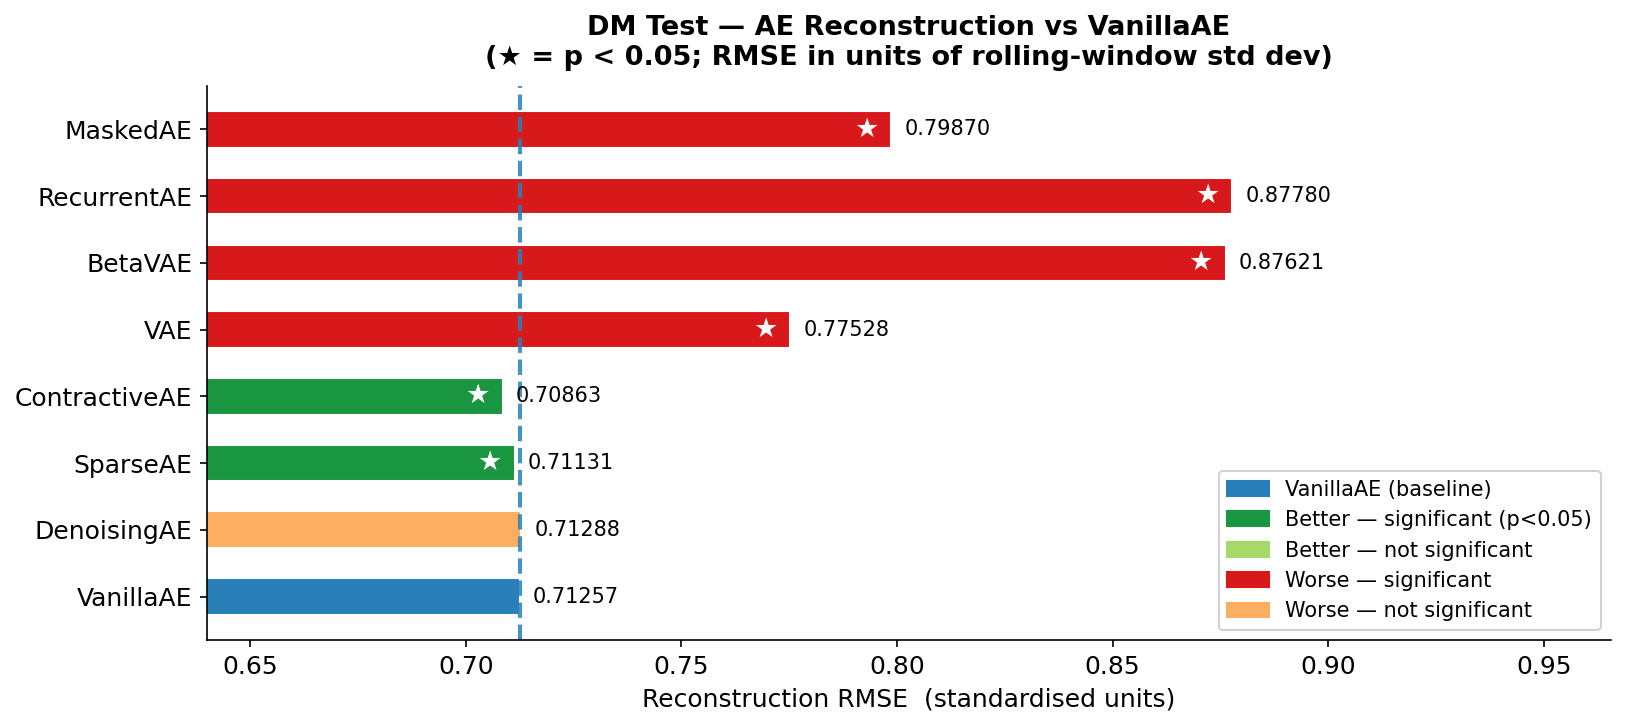

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

C_BETTER_SIG  = '#1a9641'
C_BETTER_NSIG = '#a6d96a'
C_WORSE_SIG   = '#d7191c'
C_WORSE_NSIG  = '#fdae61'
C_BASELINE    = '#2980b9'

def _bar_color(ae, dm_df, baseline):
    if ae == baseline:
        return C_BASELINE
    if ae not in dm_df.index:
        return '#95a5a6'
    sig    = dm_df.loc[ae, 'Sig (5%)'] == 'Yes'
    better = dm_df.loc[ae, 'Direction'] == 'Better'
    if better and sig:     return C_BETTER_SIG
    if better and not sig: return C_BETTER_NSIG
    if not better and sig: return C_WORSE_SIG
    return C_WORSE_NSIG

# --- Chart 4: Reconstruction RMSE coloured by DM significance vs VanillaAE ---
ae_list = [ae for ae in AE_ORDER if ae in recon.index]
rmse_s4 = [float(np.sqrt(recon.loc[ae, 'ALL'])) for ae in ae_list]
baseline_rmse = float(np.sqrt(recon.loc['VanillaAE', 'ALL']))

fig, ax = plt.subplots(figsize=(11, 5))
colors_s4 = [_bar_color(ae, dm_ae, 'VanillaAE') for ae in ae_list]
ax.barh(ae_list, rmse_s4, color=colors_s4, height=0.55, edgecolor='white')
ax.axvline(baseline_rmse, color=C_BASELINE, linewidth=2, linestyle='--', alpha=0.85, label='VanillaAE baseline')

for i, (ae, v) in enumerate(zip(ae_list, rmse_s4)):
    ax.text(v + 0.003, i, f'{v:.5f}', va='center', fontsize=10)
    if ae != 'VanillaAE' and ae in dm_ae.index and dm_ae.loc[ae, 'Sig (5%)'] == 'Yes':
        ax.text(v - 0.003, i, '★', va='center', ha='right', fontsize=13, color='white', fontweight='bold')

ax.set_xlabel('Reconstruction RMSE  (standardised units)', fontsize=12)
ax.set_title('DM Test — AE Reconstruction vs VanillaAE\n(★ = p < 0.05; RMSE in units of rolling-window std dev)', fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(0.64, max(rmse_s4) * 1.10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_patches = [
    mpatches.Patch(color=C_BASELINE,    label='VanillaAE (baseline)'),
    mpatches.Patch(color=C_BETTER_SIG,  label='Better — significant (p<0.05)'),
    mpatches.Patch(color=C_BETTER_NSIG, label='Better — not significant'),
    mpatches.Patch(color=C_WORSE_SIG,   label='Worse — significant'),
    mpatches.Patch(color=C_WORSE_NSIG,  label='Worse — not significant'),
]
ax.legend(handles=legend_patches, fontsize=10, loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig('chart_s4_ae_dm.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. HAC t-test (Diebold-Mariano) — Autoencoders + Time Series vs VanillaAE

In [10]:
vanilla_best_ts  = fc_pivot.loc['VanillaAE'].idxmin()
baseline_key     = f'VanillaAE/{vanilla_best_ts}'
baseline_fc_rmse = round(float(np.sqrt(fc_pivot.loc['VanillaAE', vanilla_best_ts])), 5)
baseline_label   = f'VanillaAE + {TS_LABELS.get(vanilla_best_ts, vanilla_best_ts)}'

rows = []
for ae in AE_ORDER:
    if ae == 'VanillaAE':
        continue
    best_ts = fc_pivot.loc[ae].idxmin()
    key     = f'{ae}/{best_ts}'
    if key not in fc_errors or baseline_key not in fc_errors:
        continue
    stat, pval = dm_test(fc_errors[key], fc_errors[baseline_key])
    rows.append({
        'AE': ae,
        'Best TS': TS_LABELS.get(best_ts, best_ts),
        'RMSE': round(float(np.sqrt(fc_pivot.loc[ae, best_ts])), 5),
        f'Baseline RMSE ({baseline_label})': baseline_fc_rmse,
        'DM Stat': round(stat, 3),
        'p-value': round(pval, 4),
        'Sig (5%)': 'Yes' if pval < 0.05 else 'No',
        'Direction': 'Better' if stat < 0 else 'Worse',
    })

dm_aets = pd.DataFrame(rows).set_index('AE')
print(f'5. DM Test - AE+TS (best combo per AE) vs {baseline_label}')
print('Negative DM stat = AE+TS beats VanillaAE baseline in forecast RMSE')
display(dm_aets)

5. DM Test - AE+TS (best combo per AE) vs VanillaAE + GARCH
Negative DM stat = AE+TS beats VanillaAE baseline in forecast RMSE


,Best TS,RMSE,Baseline RMSE (VanillaAE + GARCH),DM Stat,p-value,Sig (5%),Direction
AE,,,,,,,
DenoisingAE,GARCH,0.99476,0.99482,-1.091,0.2752,No,Better
SparseAE,GARCH,0.99477,0.99482,-1.633,0.1025,No,Better
ContractiveAE,GARCH,0.99454,0.99482,-3.240,0.0012,Yes,Better
VAE,GARCH,0.99433,0.99482,-1.329,0.1839,No,Better
BetaVAE,MA (BIC),0.99363,0.99482,-3.099,0.0019,Yes,Better
RecurrentAE,GARCH,1.08430,0.99482,51.108,0.0000,Yes,Worse
MaskedAE,GARCH,0.99460,0.99482,-0.700,0.4837,No,Better


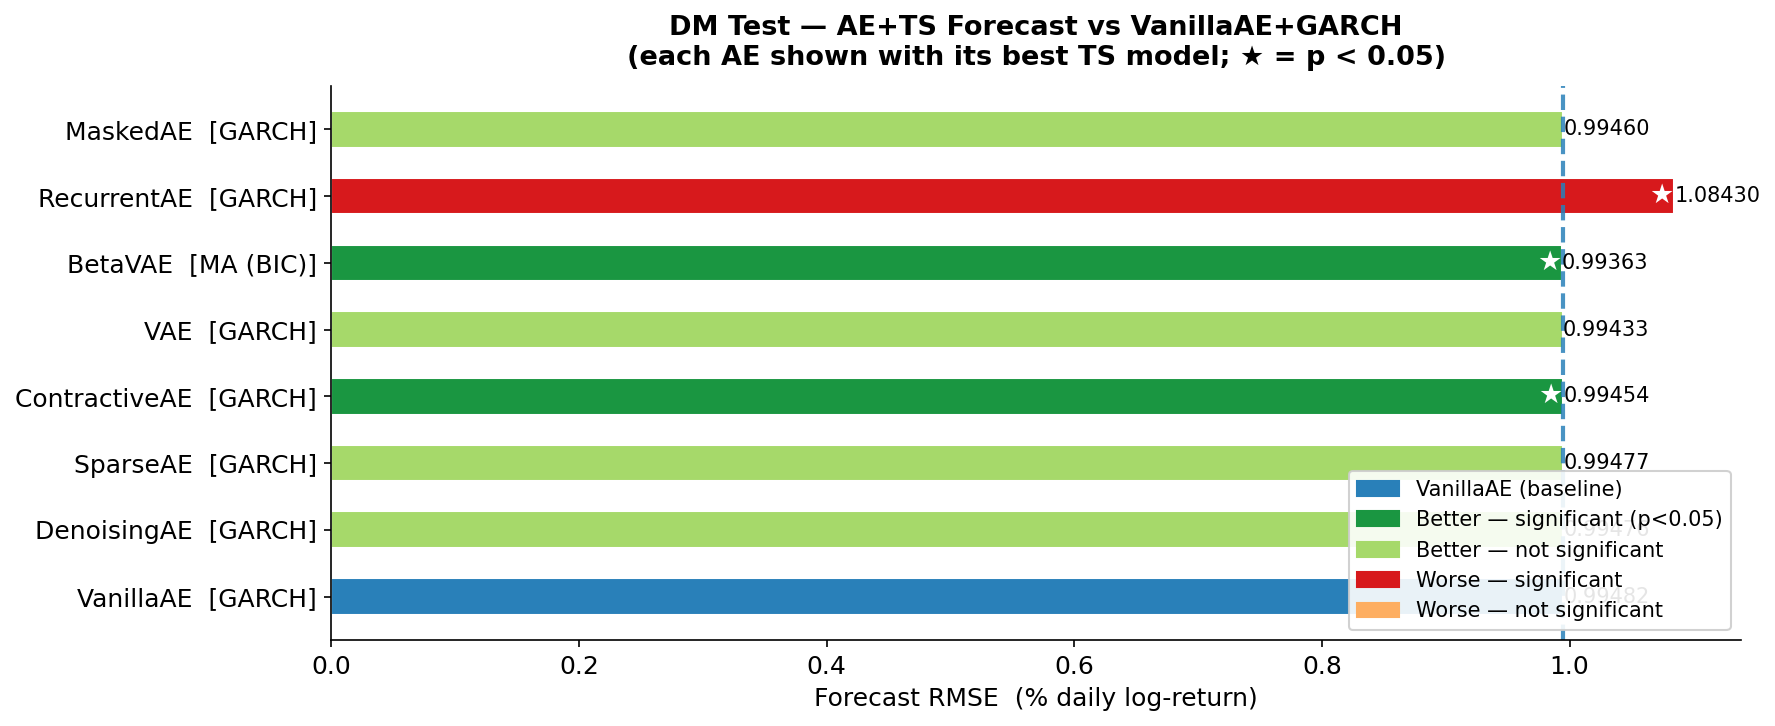

In [11]:
# --- Chart 5: Forecast RMSE (best TS per AE) coloured by DM significance vs VanillaAE+GARCH ---
full_ae_list = [ae for ae in AE_ORDER if ae in fc_pivot.index]
best_ts_map  = {ae: fc_pivot.loc[ae].idxmin() for ae in full_ae_list}
rmse_s5      = [float(np.sqrt(fc_pivot.loc[ae, best_ts_map[ae]])) for ae in full_ae_list]
baseline_s5  = float(np.sqrt(fc_pivot.loc['VanillaAE', best_ts_map['VanillaAE']]))
y_labels_s5  = [f'{ae}  [{TS_LABELS.get(best_ts_map[ae], best_ts_map[ae])}]' for ae in full_ae_list]

fig, ax = plt.subplots(figsize=(12, 5))
colors_s5 = [_bar_color(ae, dm_aets, 'VanillaAE') for ae in full_ae_list]
ax.barh(y_labels_s5, rmse_s5, color=colors_s5, height=0.55, edgecolor='white')
ax.axvline(baseline_s5, color=C_BASELINE, linewidth=2, linestyle='--', alpha=0.85)

for i, (ae, v) in enumerate(zip(full_ae_list, rmse_s5)):
    ax.text(v + 0.0003, i, f'{v:.5f}', va='center', fontsize=10)
    if ae != 'VanillaAE' and ae in dm_aets.index and dm_aets.loc[ae, 'Sig (5%)'] == 'Yes':
        ax.text(v - 0.0002, i, '★', va='center', ha='right', fontsize=13, color='white', fontweight='bold')

ax.set_xlabel('Forecast RMSE  (% daily log-return)', fontsize=12)
ax.set_title('DM Test — AE+TS Forecast vs VanillaAE+GARCH\n(each AE shown with its best TS model; ★ = p < 0.05)', fontsize=13, fontweight='bold', pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(handles=legend_patches, fontsize=10, loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig('chart_s5_aets_dm.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Time Series Only vs AE + Time Series

In [12]:
rows = []
for cl_key, (cl_label, fa_key) in CLASSICAL_MAP.items():
    if cl_key not in classical_errors or fa_key not in fc_pivot.columns:
        continue
    cl_err    = classical_errors[cl_key]
    cl_rmse   = round(float(np.sqrt((cl_err.to_numpy() ** 2).mean())), 5)
    best_ae   = fc_pivot[fa_key].idxmin()
    ae_key    = f'{best_ae}/{fa_key}'
    best_rmse = round(float(np.sqrt(fc_pivot.loc[best_ae, fa_key])), 5)
    if ae_key in fc_errors:
        stat, pval = dm_test(fc_errors[ae_key], cl_err)
        sig  = 'Yes' if pval < 0.05 else 'No'
        dirn = 'AE Better' if stat < 0 else 'Classical Better'
        dm_val, pv_val = round(stat, 3), round(pval, 4)
    else:
        dm_val, pv_val, sig, dirn = float('nan'), float('nan'), 'N/A', 'N/A'
    rows.append({
        'TS Model': cl_label,
        'Classical RMSE (no AE)': cl_rmse,
        'Best AE+TS RMSE': best_rmse,
        'Best AE': best_ae,
        'DM Stat': dm_val,
        'p-value': pv_val,
        'Sig (5%)': sig,
        'Direction': dirn,
    })

dm_ts_vs_aets = pd.DataFrame(rows).set_index('TS Model')
print('6a. TS Only vs AE+TS: DM test per TS family')
print('Negative DM stat = AE+TS has lower forecast error than classical TS alone')
display(dm_ts_vs_aets)

6a. TS Only vs AE+TS: DM test per TS family
Negative DM stat = AE+TS has lower forecast error than classical TS alone


,Classical RMSE (no AE),Best AE+TS RMSE,Best AE,DM Stat,p-value,Sig (5%),Direction
TS Model,,,,,,,
AR (AIC),1.00603,0.99457,BetaVAE,-12.429,0.0000,Yes,AE Better
AR (BIC),0.99912,0.99410,BetaVAE,-7.420,0.0000,Yes,AE Better
MA (AIC),1.00057,0.99428,BetaVAE,-8.791,0.0000,Yes,AE Better
MA (BIC),0.99644,0.99363,BetaVAE,-5.090,0.0000,Yes,AE Better
ARIMA (AIC),1.26450,0.99549,BetaVAE,-40.424,0.0000,Yes,AE Better
ARIMA (BIC),1.03207,0.99430,BetaVAE,-9.395,0.0000,Yes,AE Better
"GARCH(1,1)",0.99550,0.99366,BetaVAE,-3.590,0.0003,Yes,AE Better


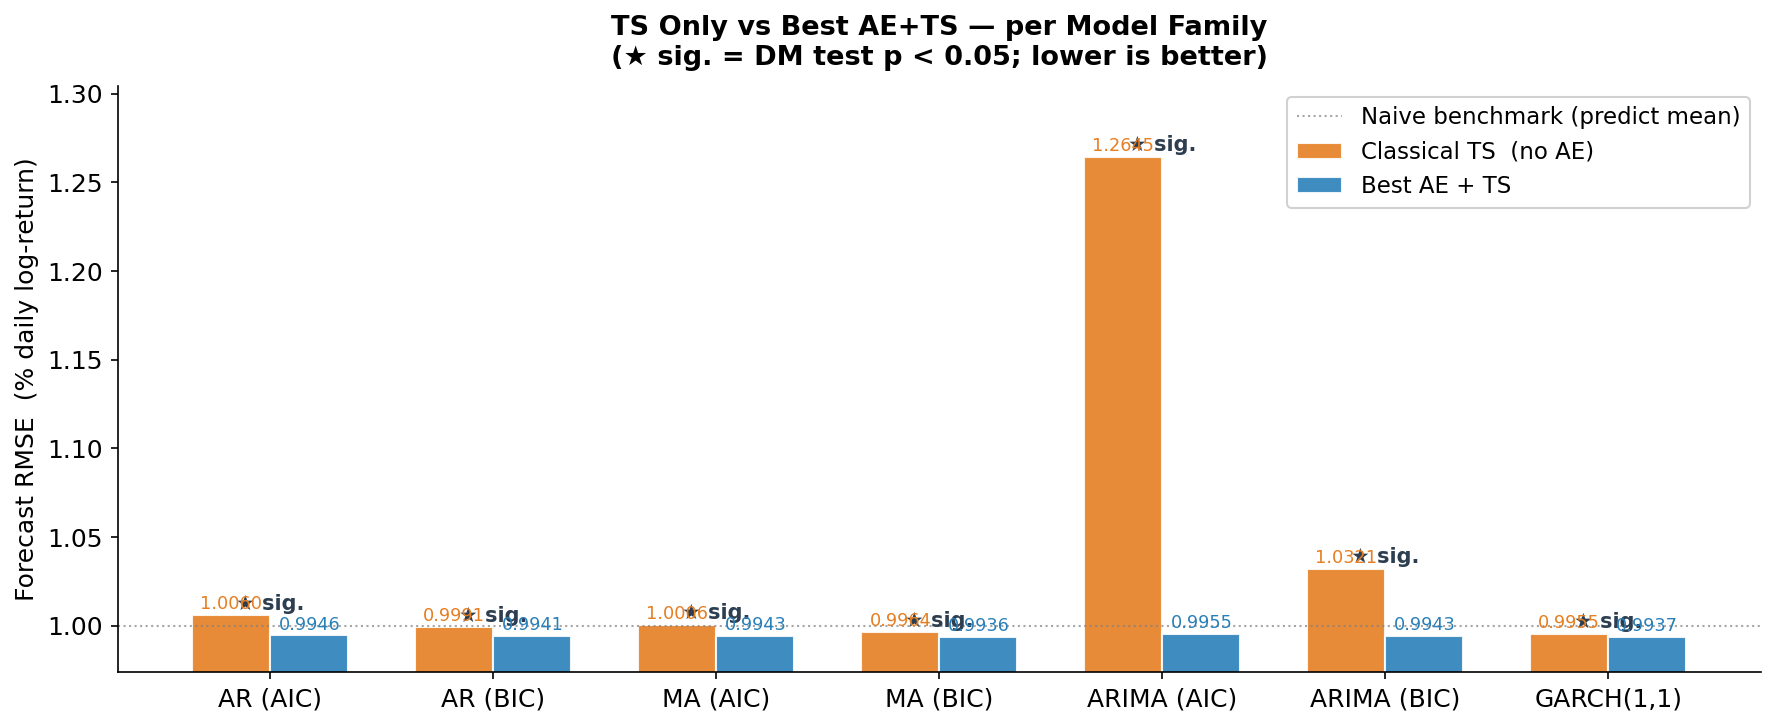

In [13]:
# --- Chart 6a: Classical TS vs Best AE+TS RMSE per model family ---
ts_names = list(dm_ts_vs_aets.index)
cl_rmse  = dm_ts_vs_aets['Classical RMSE (no AE)'].values
ae_rmse  = dm_ts_vs_aets['Best AE+TS RMSE'].values
sigs_6a  = (dm_ts_vs_aets['Sig (5%)'] == 'Yes').values

x = np.arange(len(ts_names))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, cl_rmse, width=w, label='Classical TS  (no AE)', color='#e67e22', alpha=0.9, edgecolor='white')
ax.bar(x + w/2, ae_rmse, width=w, label='Best AE + TS',           color='#2980b9', alpha=0.9, edgecolor='white')

for i, (cl, ae_v, sig) in enumerate(zip(cl_rmse, ae_rmse, sigs_6a)):
    top = max(cl, ae_v) + 0.003
    label = '★ sig.' if sig else 'n.s.'
    color = '#2c3e50' if sig else '#7f8c8d'
    ax.text(i, top, label, ha='center', fontsize=10, color=color, fontweight='bold' if sig else 'normal')
    ax.text(i - w/2, cl + 0.001, f'{cl:.4f}', ha='center', va='bottom', fontsize=8.5, color='#e67e22')
    ax.text(i + w/2, ae_v + 0.001, f'{ae_v:.4f}', ha='center', va='bottom', fontsize=8.5, color='#2980b9')

ax.axhline(1.0, color='gray', linewidth=1, linestyle=':', alpha=0.7, label='Naive benchmark (predict mean)')
ax.set_xticks(x)
ax.set_xticklabels(ts_names, fontsize=12)
ax.set_ylabel('Forecast RMSE  (% daily log-return)', fontsize=12)
ax.set_title('TS Only vs Best AE+TS — per Model Family\n(★ sig. = DM test p < 0.05; lower is better)', fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=11, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
y_min = min(min(cl_rmse), min(ae_rmse)) - 0.02
ax.set_ylim(y_min, max(max(cl_rmse), max(ae_rmse)) + 0.04)
plt.tight_layout()
plt.savefig('chart_s6a_ts_vs_aets.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
garch_err  = classical_errors['GARCH11']
garch_rmse = round(float(np.sqrt((garch_err.to_numpy() ** 2).mean())), 5)

rows = []
for key, err_df in fc_errors.items():
    ae, ts   = key.split('/')
    stat, pval = dm_test(err_df, garch_err)
    rmse       = round(float(np.sqrt((err_df.to_numpy() ** 2).mean())), 5)
    rows.append({
        'AE': ae,
        'TS Model': TS_LABELS.get(ts, ts),
        'AE+TS RMSE': rmse,
        'GARCH(1,1) RMSE': garch_rmse,
        'DM Stat': round(stat, 3),
        'p-value': round(pval, 4),
        'Sig (5%)': 'Yes' if pval < 0.05 else 'No',
        'Direction': 'Better than GARCH' if stat < 0 else 'Worse than GARCH',
    })

all_vs_garch = (pd.DataFrame(rows)
                .set_index(['AE', 'TS Model'])
                .sort_values('p-value'))
print(f'6b. All AE+TS combinations vs GARCH(1,1) - sorted by most significant p-value')
print(f'GARCH(1,1) Pooled RMSE: {garch_rmse}')
print('Negative DM stat = AE+TS beats GARCH')
display(all_vs_garch)

6b. All AE+TS combinations vs GARCH(1,1) - sorted by most significant p-value
GARCH(1,1) Pooled RMSE: 0.9955
Negative DM stat = AE+TS beats GARCH


AE+TS RMSE  GARCH(1,1) RMSE  DM Stat  p-value  \
AE            TS Model                                                     
VanillaAE     AR (AIC)        1.00145           0.9955    6.807   0.0000   
VAE           ARIMA (AIC)     1.00640           0.9955   11.219   0.0000   
MaskedAE      ARIMA (BIC)     1.00854           0.9955    9.322   0.0000   
ContractiveAE ARIMA (BIC)     1.02143           0.9955   15.212   0.0000   
              ARIMA (AIC)     1.07155           0.9955   29.166   0.0000   
RecurrentAE   AR (AIC)        1.09091           0.9955   50.142   0.0000   
              AR (BIC)        1.08615           0.9955   49.519   0.0000   
ContractiveAE AR (AIC)        0.99986           0.9955    5.339   0.0000   
RecurrentAE   MA (AIC)        1.08704           0.9955   49.444   0.0000   
SparseAE      ARIMA (BIC)     1.01436           0.9955   14.150   0.0000   
RecurrentAE   MA (BIC)        1.08443           0.9955   49.035   0.0000   
              ARIMA (AIC)     1.30027           0.9955   45.387   0.0000   
SparseAE      AR (AIC)        1.00112           0.9955    6.529   0.0000   
              ARIMA (AIC)     1.06115           0.9955   28.964   0.0000   
DenoisingAE   ARIMA (BIC)     1.01740           0.9955   13.509   0.0000   
MaskedAE      ARIMA (AIC)     1.04335           0.9955   20.776   0.0000   
RecurrentAE   ARIMA (BIC)     1.16995           0.9955   32.589   0.0000   
VanillaAE     ARIMA (BIC)     1.01818           0.9955   13.279   0.0000   
DenoisingAE   AR (AIC)        1.00079           0.9955    6.208   0.0000   
MaskedAE      AR (AIC)        0.99955           0.9955    4.802   0.0000   
VanillaAE     ARIMA (AIC)     1.06361           0.9955   28.002   0.0000   
RecurrentAE   GARCH           1.08430           0.9955   49.484   0.0000   
DenoisingAE   ARIMA (AIC)     1.06805           0.9955   27.857   0.0000   
SparseAE      MA (AIC)        0.99823           0.9955    3.874   0.0001   
VanillaAE     MA (AIC)        0.99828           0.9955    3.925   0.0001   
BetaVAE       GARCH           0.99366           0.9955   -3.590   0.0003   
              MA (BIC)        0.99363           0.9955   -3.647   0.0003   
DenoisingAE   MA (AIC)        0.99802           0.9955    3.607   0.0003   
ContractiveAE MA (AIC)        0.99781           0.9955    3.363   0.0008   
VAE           ARIMA (BIC)     0.99725           0.9955    2.795   0.0052   
BetaVAE       AR (BIC)        0.99410           0.9955   -2.571   0.0101   
VAE           GARCH           0.99433           0.9955   -2.364   0.0181   
BetaVAE       MA (AIC)        0.99428           0.9955   -2.208   0.0272   
              ARIMA (BIC)     0.99430           0.9955   -2.186   0.0288   
MaskedAE      MA (AIC)        0.99692           0.9955    2.130   0.0331   
VAE           MA (BIC)        0.99444           0.9955   -2.126   0.0335   
              AR (AIC)        0.99694           0.9955    2.044   0.0409   
VanillaAE     AR (BIC)        0.99678           0.9955    1.981   0.0476   
ContractiveAE GARCH           0.99454           0.9955   -1.840   0.0657   
MaskedAE      GARCH           0.99460           0.9955   -1.750   0.0800   
SparseAE      AR (BIC)        0.99661           0.9955    1.731   0.0834   
DenoisingAE   AR (BIC)        0.99653           0.9955    1.620   0.1053   
ContractiveAE MA (BIC)        0.99465           0.9955   -1.606   0.1083   
BetaVAE       AR (AIC)        0.99457           0.9955   -1.571   0.1162   
MaskedAE      MA (BIC)        0.99472           0.9955   -1.486   0.1374   
DenoisingAE   GARCH           0.99476           0.9955   -1.378   0.1683   
SparseAE      GARCH           0.99477           0.9955   -1.353   0.1760   
VanillaAE     GARCH           0.99482           0.9955   -1.257   0.2087   
MaskedAE      AR (BIC)        0.99620           0.9955    1.157   0.2472   
SparseAE      MA (BIC)        0.99495           0.9955   -1.002   0.3166   
DenoisingAE   MA (BIC)        0.99495           0.9955   -0.997   0.3186   

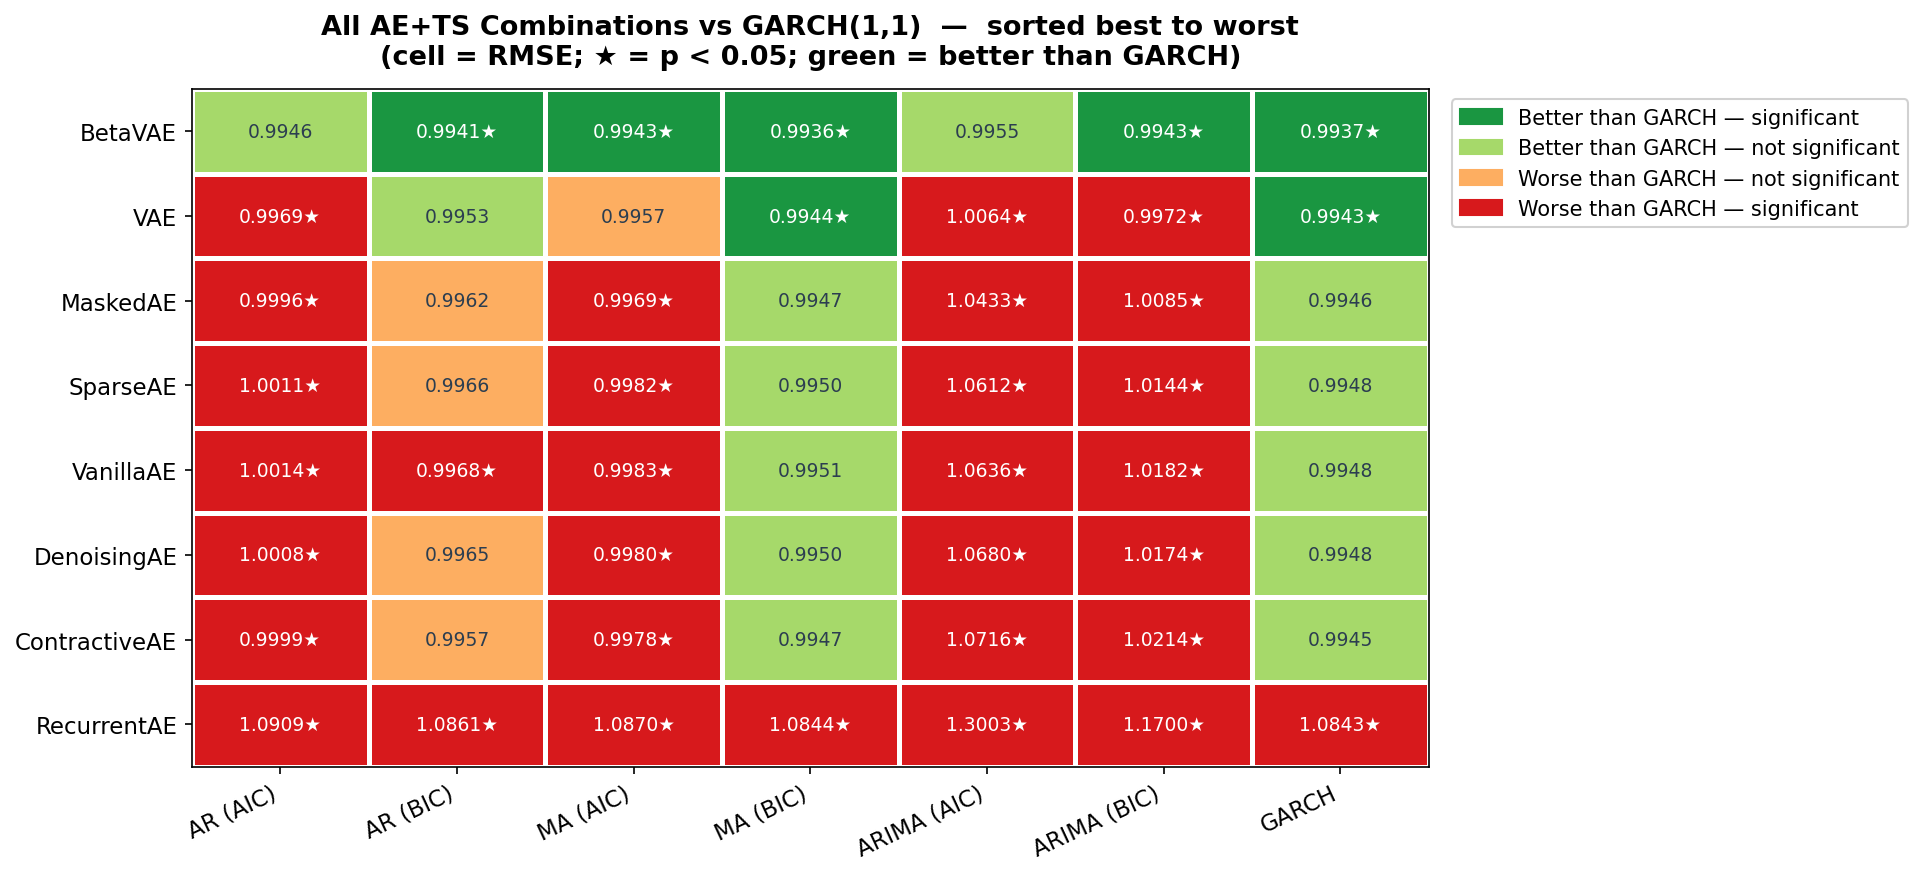

In [15]:
# --- Chart 6b: Heatmap — all AE+TS vs GARCH(1,1), sorted best→worst vs GARCH ---
ts_col_order = [TS_LABELS[t] for t in TS_ORDER if TS_LABELS[t] in all_vs_garch.index.get_level_values('TS Model')]

# Sort AEs by average RMSE across all TS models (ascending = best vs GARCH at top)
avg_rmse_per_ae = all_vs_garch.groupby('AE')['AE+TS RMSE'].mean()
ae_row_order = [ae for ae in avg_rmse_per_ae.sort_values().index if ae in AE_ORDER]

dir_heat  = (all_vs_garch['Direction'] == 'Better than GARCH').unstack('TS Model').reindex(index=ae_row_order, columns=ts_col_order)
sig_heat  = (all_vs_garch['Sig (5%)'] == 'Yes').unstack('TS Model').reindex(index=ae_row_order, columns=ts_col_order)
rmse_heat = all_vs_garch['AE+TS RMSE'].unstack('TS Model').reindex(index=ae_row_order, columns=ts_col_order)

n_ae = len(ae_row_order)
n_ts = len(ts_col_order)

# Build integer category matrix: 0=better+sig, 1=better+nsig, 2=worse+nsig, 3=worse+sig
cat = np.zeros((n_ae, n_ts), dtype=int)
for i, ae in enumerate(ae_row_order):
    for j, ts in enumerate(ts_col_order):
        better = bool(dir_heat.loc[ae, ts])
        sig    = bool(sig_heat.loc[ae, ts])
        if better and sig:       cat[i, j] = 0
        elif better:             cat[i, j] = 1
        elif not better and sig: cat[i, j] = 3
        else:                    cat[i, j] = 2

cmap = mcolors.ListedColormap([C_BETTER_SIG, C_BETTER_NSIG, C_WORSE_NSIG, C_WORSE_SIG])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

fig, ax = plt.subplots(figsize=(13, 6))
ax.pcolormesh(cat, cmap=cmap, norm=norm, edgecolors='white', linewidth=1.5)

for i, ae in enumerate(ae_row_order):
    for j, ts in enumerate(ts_col_order):
        rmse = rmse_heat.loc[ae, ts]
        sig  = sig_heat.loc[ae, ts]
        txt  = f'{rmse:.4f}{"★" if sig else ""}'
        text_color = 'white' if cat[i, j] in (0, 3) else '#2c3e50'
        ax.text(j + 0.5, i + 0.5, txt, ha='center', va='center', fontsize=9, color=text_color)

ax.set_xticks(np.arange(n_ts) + 0.5)
ax.set_xticklabels(ts_col_order, fontsize=11, rotation=25, ha='right')
ax.set_yticks(np.arange(n_ae) + 0.5)
ax.set_yticklabels(ae_row_order, fontsize=11)
ax.invert_yaxis()   # best (lowest avg RMSE) at top
ax.set_title('All AE+TS Combinations vs GARCH(1,1)  —  sorted best to worst\n(cell = RMSE; ★ = p < 0.05; green = better than GARCH)', fontsize=13, fontweight='bold', pad=12)

legend_patches_6b = [
    mpatches.Patch(color=C_BETTER_SIG,  label='Better than GARCH — significant'),
    mpatches.Patch(color=C_BETTER_NSIG, label='Better than GARCH — not significant'),
    mpatches.Patch(color=C_WORSE_NSIG,  label='Worse than GARCH — not significant'),
    mpatches.Patch(color=C_WORSE_SIG,   label='Worse than GARCH — significant'),
]
ax.legend(handles=legend_patches_6b, fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.savefig('chart_s6b_all_vs_garch.png', dpi=150, bbox_inches='tight')
plt.show()